In [1]:
# import modules
import datacube
import joblib
import numpy as np
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap
from dea_tools.classification import sklearn_flatten, sklearn_unflatten 
from dea_tools.datahandling import load_ard
from dea_tools.plotting import display_map, rgb
from odc.algo import mask_cleanup
from datacube.utils.cog import write_cog

In [2]:
import sklearn
print(sklearn.__version__)

1.3.2


In [3]:
#define colour scale for plotting 
colours = [(0.87, 0, 0), (1, 1, 0.73), (0.165, 0.615, 0.957)]
cmap = LinearSegmentedColormap.from_list('fmc', colours, N=256)

In [4]:
dc = datacube.Datacube(app='fmc')

/env/lib/python3.10/site-packages/datacube/drivers/driver_cache.py:54: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import iter_entry_points


In [5]:
def classify_FMC(data, model):
    """
    - data (xarray.Dataset): Sentinel-2 dataset containing required bands and optional multiple time steps. 
        
    - model (sklearn model): A pre-trained model for classification.
    
    Returns:
    - xarray.Dataset: A dataset containing the classified FMC results.
"""
    #calculate NDVI and NDII

    data['ndii']=((data.nbart_nir_1-data.nbart_swir_2)/(data.nbart_nir_1+data.nbart_swir_2))
    data['ndvi']=((data.nbart_nir_1-data.nbart_red)/(data.nbart_nir_1+data.nbart_red))

    # change order of variables to be the same as the model expects
    data_neworder = data[['ndvi','ndii', 'nbart_blue','nbart_green','nbart_red','nbart_red_edge_1' ,'nbart_red_edge_2' ,'nbart_red_edge_3','nbart_nir_1','nbart_nir_2','nbart_swir_2','nbart_swir_3']] 
    
    #flattern the data using SKlearn_flatten
    data_flat = sklearn_flatten(data_neworder)
    
    # Replace inf and -inf with no_data_value
    data_flat = np.where(np.isinf(data_flat), -999, data_flat)
    
    #classify the data using the model
    print("predicting...")
    out_class = model.predict(data_flat)
    
    #return_classification to original shape
    #transpose because coords sideways when moving from Numpy to Xarray
    returned_result = sklearn_unflatten(out_class, data).transpose()
    
    #make results a dataset
    dataset_result = xr.Dataset({'LFMC':returned_result}, coords=data.coords, attrs=data.attrs)
    
    #return
    return dataset_result

In [6]:
# import model
model = joblib.load('/home/jovyan/gdata1/projects/Hazards/Fuel_moisture/RF_AllBands_noLC_DEA_labeless.joblib')


/env/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/env/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [7]:
# find a single S2 dataset: 26cce90f-c8f9-4234-835c-35005454f62b

dataset_uuid = "ae2f964d-7a4f-4af3-b78c-8a2a2520491b"
# datasets=[dc.index.datasets.get(dataset_uuid)],
df = dc.load(datasets=[dc.index.datasets.get(dataset_uuid)],
            measurements= ['nbart_blue','nbart_green','nbart_red','nbart_red_edge_1' ,'nbart_red_edge_2' ,'nbart_red_edge_3','nbart_nir_1','nbart_nir_2','nbart_swir_2','nbart_swir_3', 'oa_fmask'],
            resolution=(-20, 20),
            time = ('2024-11-01','2024-11-15', ),


            output_crs= 'EPSG:3577')

# Check if the dataset is loaded
df

/env/lib/python3.10/site-packages/datacube/utils/geometry/_base.py:623: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type in ['Point', 'MultiPoint']:
/env/lib/python3.10/site-packages/datacube/utils/geometry/_base.py:626: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type in ['GeometryCollection', 'MultiPolygon', 'MultiLineString']:
/env/lib/python3.10/site-packages/datacube/utils/geometry/_base.py:629: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type in ['LineString', 'LinearRing']:
/env/lib/python3.10/site-packages/datacube/utils/geometry/_base.py:632: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use

<xarray.Dataset> Size: 775MB
Dimensions:           (time: 1, y: 6077, x: 6074)
Coordinates:
  * time              (time) datetime64[ns] 8B 2021-05-29T00:06:46.861625
  * y                 (y) float64 49kB -3.941e+06 -3.941e+06 ... -4.062e+06
  * x                 (x) float64 49kB 1.446e+06 1.446e+06 ... 1.567e+06
    spatial_ref       int32 4B 3577
Data variables:
    nbart_blue        (time, y, x) int16 74MB -999 -999 -999 ... -999 -999 -999
    nbart_green       (time, y, x) int16 74MB -999 -999 -999 ... -999 -999 -999
    nbart_red         (time, y, x) int16 74MB -999 -999 -999 ... -999 -999 -999
    nbart_red_edge_1  (time, y, x) int16 74MB -999 -999 -999 ... -999 -999 -999
    nbart_red_edge_2  (time, y, x) int16 74MB -999 -999 -999 ... -999 -999 -999
    nbart_red_edge_3  (time, y, x) int16 74MB -999 -999 -999 ... -999 -999 -999
    nbart_nir_1       (time, y, x) int16 74MB -999 -999 -999 ... -999 -999 -999
    nbart_nir_2       (time, y, x) int16 74MB -999 -999 -999 ... -999 -999 -999
    nbart_swir_2      (time, y, x) int16 74MB -999 -999 -999 ... -999 -999 -999
    nbart_swir_3      (time, y, x) int16 74MB -999 -999 -999 ... -999 -999 -999
    oa_fmask          (time, y, x) uint8 37MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [8]:
# Define masks. seperate cloud + shadow mask from water+ no_data mask becasue we want to do buffering of could+shadow but not water+no_data

cloud_mask = (df.oa_fmask == 2) | (df.oa_fmask == 3)
water_mask = (df.oa_fmask == 5) | (df.oa_fmask == 0)

In [9]:
#perfrom 1 pixel opening on cloud + shadow. three pixle dilation 
better_cloud_mask = mask_cleanup(mask=cloud_mask, mask_filters=[("opening", 1),("dilation", 3)])

#drop fmask from dataset before we classify
df = df.drop(['oa_fmask'])

/tmp/ipykernel_1105/2683096031.py:5: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df = df.drop(['oa_fmask'])


In [10]:
#perfrom calssification of data usinf model defined above
FMC_data = classify_FMC(df, model)

predicting...


In [11]:
#apply masks we generated before to classified data. it can be masked before we classify but then these pixels have a 0 value and it is better if it is 'no data'

masked_data = FMC_data.where(~better_cloud_mask)
masked_data = masked_data.where(~water_mask)

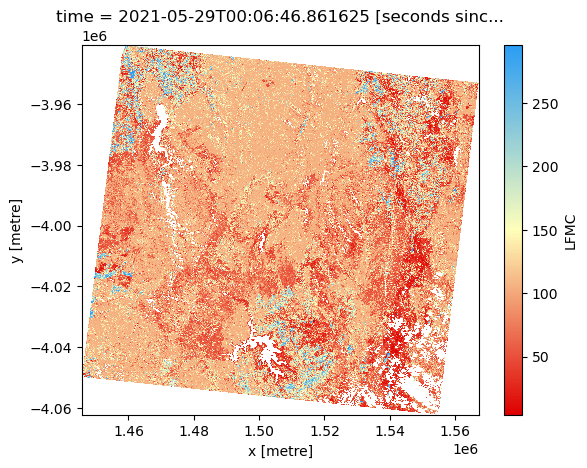

In [12]:
masked_data.LFMC.plot(cmap=cmap)

In [13]:
# Make the no data be -999 not np.nan

masked_data = masked_data.where(masked_data >= 0, -999).astype('int16')

#make the data be a 16 bit int rather than a floating point. 

In [14]:
time_string = str(masked_data.time.data)
time_string= time_string[2:12]

In [15]:
time_string

'2021-05-29'

In [16]:

# save to file

write_cog(masked_data.LFMC, fname=f'sandbox_FMC_Not_bilenear_{time_string}.tif')

PosixPath('sandbox_FMC_Not_bilenear_2021-05-29.tif')

In [17]:
! pip list


Package                           Version
--------------------------------- --------------------
absl-py                           2.1.0
access                            1.1.9
affine                            2.4.0
aiobotocore                       2.15.1
aiohappyeyeballs                  2.4.3
aiohttp                           3.10.10
aioitertools                      0.12.0
aiosignal                         1.3.1
alabaster                         1.0.0
alembic                           1.13.3
amply                             0.1.6
annotated-types                   0.7.0
anyio                             4.6.2.post1
apache-sedona                     1.6.1
argon2-cffi                       23.1.0
argon2-cffi-bindings              21.2.0
arrow                             1.3.0
asciitree                         0.3.3
astropy                           6.1.4
astropy-iers-data                 0.2024.10.14.0.32.55
asttokens                         2.4.1
astunparse                        1